In [1]:
old_wd <- getwd()

setwd("../")

if (file.exists("renv/activate.R")) {
  source("renv/activate.R")
} else {
  stop("Could not find renv/activate.R in project root")
}

setwd(old_wd)

- The project is out-of-sync -- use `renv::status()` for details.


In [2]:
library(fda)

Loading required package: splines

Loading required package: fds

Loading required package: rainbow

Loading required package: MASS

Loading required package: pcaPP

Loading required package: RCurl

Loading required package: deSolve


Attaching package: ‘fda’


The following object is masked from ‘package:graphics’:

    matplot


The following object is masked from ‘package:datasets’:

    gait




$coefs
                 16         18          20          21           23          24
bspl4.1   7.0374528   4.841143  1.75690248   0.7051355   3.81498941   3.1999841
bspl4.2   0.2979082  -7.420088  2.74084871  -3.1489796  -1.49099191   8.6757094
bspl4.3   2.3627898   5.326988  6.88960531   0.5345592   4.31795199  -4.5794182
bspl4.4   0.4577224   4.117611 -5.19750404   6.7545535  -4.97959853  -4.5306455
bspl4.5  -5.5145005  -8.530033 -0.02250233  -8.4151179   1.40326623   3.9686687
bspl4.6  -0.8172606   6.100872 -8.83940857   2.9062417  -0.04182677  -7.2868458
bspl4.7  -8.0063575 -10.330886 -5.65798365  -5.4034900  -2.27123609  -2.2596379
bspl4.8   7.6647076   7.303175 -4.38122527  -5.9440570   2.60444640   2.2100252
bspl4.9   1.1743030 -12.049206 -1.54059448  -3.6700895  -5.79576982  -1.7572126
bspl4.10 -2.2128560  -3.875757 -8.50696077 -12.8799955   3.77317874   8.2819692
bspl4.11  5.3689812 -10.834965 -2.21760776  -3.3191426  -3.18007542   1.3302086
bspl4.12 -4.8381123 -10.306041 -2

[1] "done"

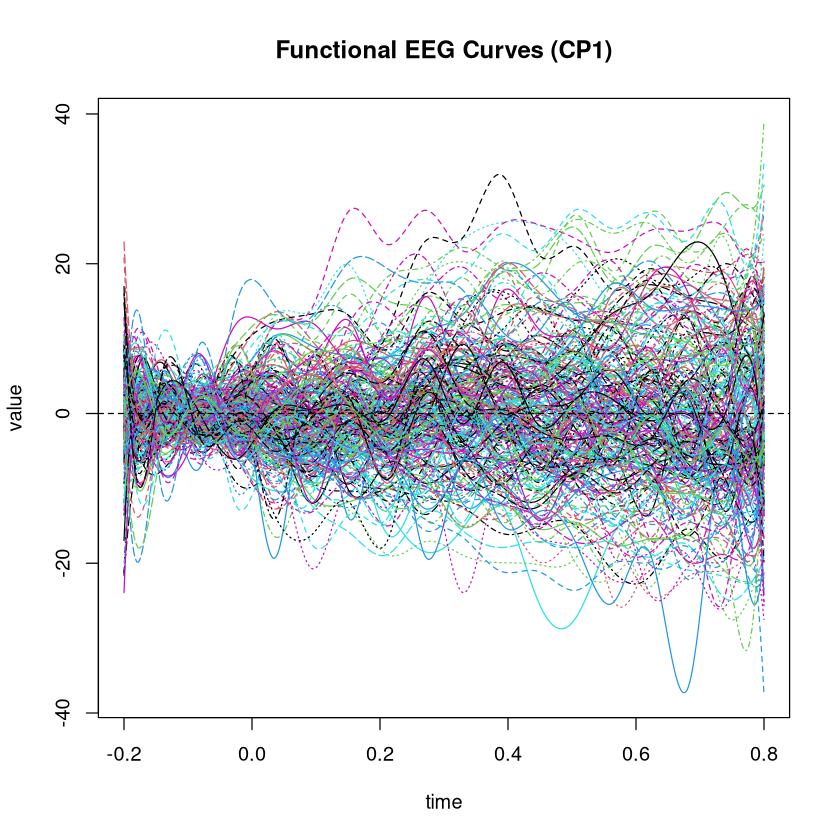

In [ ]:
eeg_df <- read.csv("./ds006018_per_stimuli/sub-001/task-auditoryoddball_Stimulus_S80.csv")


# 2. Format for FDA
# Let's say we are looking at one channel (e.g., 'Cz')
# We need a matrix where rows = time, cols = trials
eeg_matrix <- reshape2::acast(eeg_df, time ~ epoch, value.var = "CP1")


# 3. Define the Time Range and Basis
time_points <- as.numeric(rownames(eeg_matrix))
time_range <- range(time_points)

# Create a B-spline basis (common for EEG)
# nbasis should be enough to capture the peaks but small enough to smooth noise
eeg_basis <- create.bspline.basis(time_range, nbasis = 20)


# 4. Smooth the data into a Functional Data (fd) object
eeg_fd <- smooth.basis(time_points, eeg_matrix, eeg_basis)$fd
eeg_fd

# 5. Plot to verify
plot(eeg_fd, main="Functional EEG Curves (CP1)")

In [ ]:
# Load the data from the RDS file
eeg_fd <- readRDS("./ds006018_functional/sub-001/task-auditoryoddball_Stimulus_S1.rds")

[1] "done"

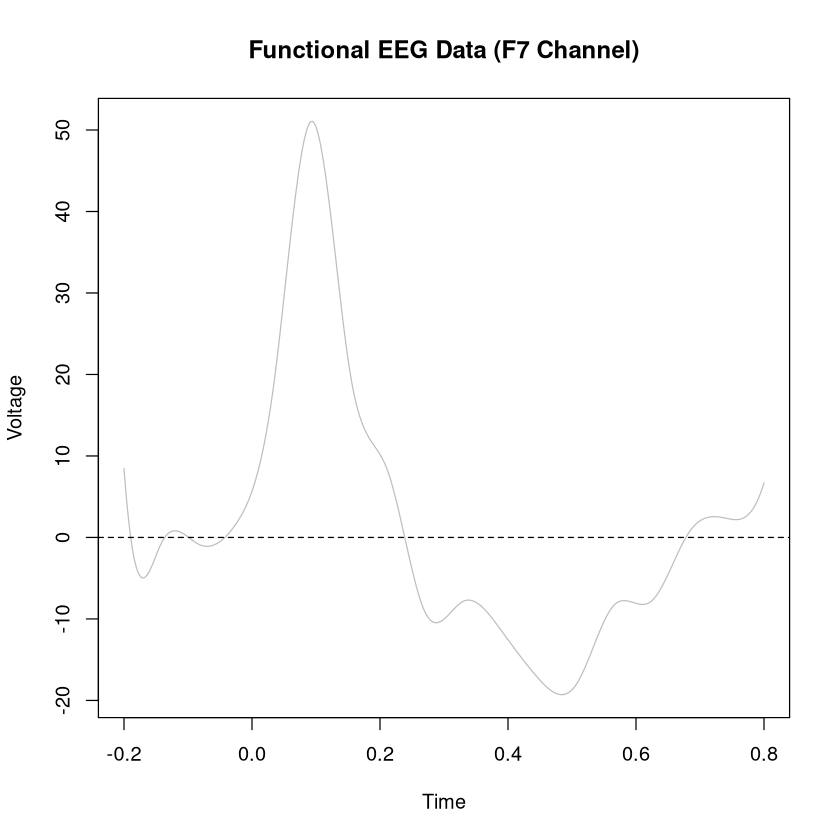

In [5]:
# 2. Re-establish classes (just in case they were lost during save/load)
class(eeg_fd) <- "fd"
class(eeg_fd$basis) <- "basisfd"

# 3. Plot ALL epochs at once
# This will show a "spaghetti plot" of all your EEG segments
plot(eeg_fd, 
     col = "gray", 
     lty = 1, 
     main = "Functional EEG Data (F7 Channel)",
     xlab = "Time", 
     ylab = "Voltage")

[1] "done"

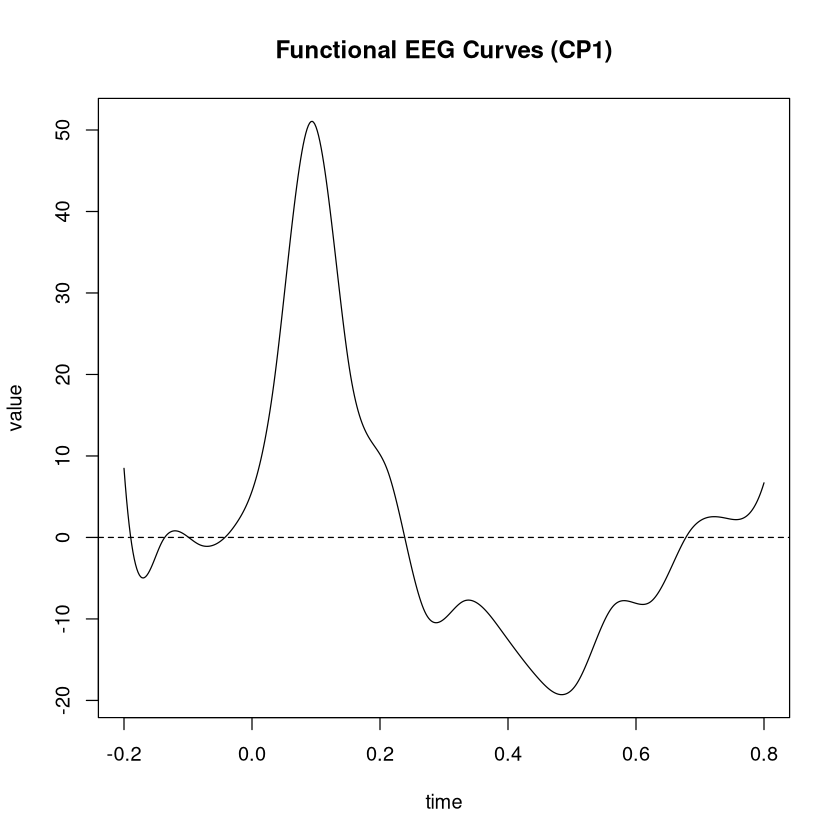

In [6]:

plot(eeg_fd, main="Functional EEG Curves (CP1)")